# 3. Registration

Aligning scans: `kabsch` for known correspondences (reflector targets), `icp`
for clouds, and `merge_scans` to bring everything into one frame.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import filters, registration as reg

Two 'scans' of the same plot: the second is a different subsample, moved by a known rigid transform that registration should undo.

In [2]:
plot = synthetic.forest()
scan_a = filters.random_subsample(plot, fraction=0.3, seed=1)
truth = reg.translation(0.6, -0.4, 0.15) @ reg.rotation_z(6.0)
scan_b = filters.random_subsample(plot, fraction=0.3, seed=2).transform(np.linalg.inv(truth))

## Targets: Kabsch

With matched points (here the four stem bases) the transform is closed-form.

In [3]:
targets_a = np.array([[x, y, synthetic.terrain_height(x, y)] for x, y, *_ in synthetic.DEFAULT_TREES])
targets_b = (np.linalg.inv(truth) @ np.c_[targets_a, np.ones(4)].T).T[:, :3]
coarse = reg.kabsch(targets_b, targets_a)
print("error vs truth:", np.abs(coarse - truth).max())

error vs truth: 3.219646771412954e-15


## Clouds: ICP

ICP refines a starting guess (identity here) as long as it lies within `max_correspondence_distance`. Point-to-plane converges in fewer iterations on surfaces such as ground and stems.

In [4]:
def report(name, T, info):
    err = np.linalg.norm((T @ np.linalg.inv(truth))[:3, 3])
    print(f"{name:16s} rmse {info['rmse']:.4f} m  iterations {info['iterations']:3d}  translation error {err * 1000:.1f} mm")

report("point-to-point", *reg.icp(scan_b, scan_a, max_correspondence_distance=1.0))
T, info = reg.icp(scan_b, scan_a, max_correspondence_distance=1.0, method="plane")
report("point-to-plane", T, info)

point-to-point   rmse 0.0530 m  iterations  24  translation error 0.4 mm


point-to-plane   rmse 0.0530 m  iterations  11  translation error 0.5 mm


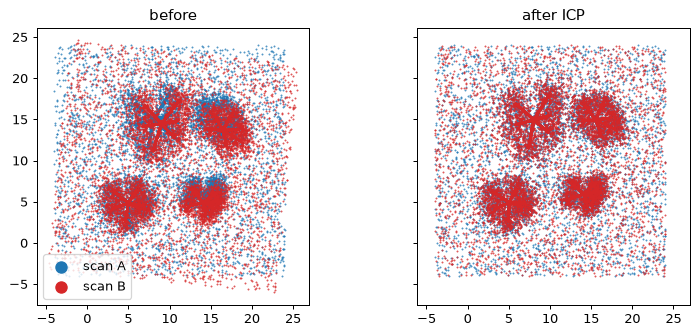

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for a, b, title in ((ax[0], scan_b, "before"), (ax[1], scan_b.transform(T), "after ICP")):
    a.scatter(scan_a.x[::4], scan_a.y[::4], s=0.2, c="C0", label="scan A")
    a.scatter(b.x[::4], b.y[::4], s=0.2, c="C3", label="scan B")
    a.set(title=title, aspect="equal")
ax[0].legend(markerscale=20);

## Partial overlap

When one scan sees things the other does not, the unmatched part drags the
solution. `trim` keeps only the closest fraction of correspondences each
iteration. Trimming throws information away, so start it from a coarse
alignment (targets, or an untrimmed run): from far off, the closest pairs are
all on the ground and the solution can slide along it.

In [6]:
rng = np.random.default_rng(0)
extra = sylva.PointCloud(rng.uniform([22, 0, 0], [30, 20, 8], (20000, 3)))      # only scan B sees this
scan_b2 = sylva.PointCloud.concatenate([scan_b.without(*scan_b.attrs), extra.transform(np.linalg.inv(truth))])
start = reg.translation(0.05, -0.04, 0.02) @ coarse                              # targets, a few cm off
report("all pairs", *reg.icp(scan_b2, scan_a, init=start, max_correspondence_distance=3.0))
report("trim 0.7", *reg.icp(scan_b2, scan_a, init=start, max_correspondence_distance=3.0, trim=0.7))

all pairs        rmse 0.5563 m  iterations  25  translation error 615.2 mm


trim 0.7         rmse 0.0094 m  iterations  12  translation error 0.1 mm


## Merging

`merge_scans` applies one transform per scan and records where each point came from.

In [7]:
merged = reg.merge_scans([scan_a, scan_b], [np.eye(4), T])
print(merged, np.bincount(merged.attrs["scan_id"]))

PointCloud(n=188,876, attrs=['classification', 'scan_id', 'tree_id']) [94438 94438]
